In [37]:
import rustworkx as rx
from rustworkx.visualization import mpl_draw as draw_graph
import numpy as np
import random

from qiskit import transpile
from qiskit.circuit import Parameter,ParameterExpression
from qiskit_algorithms import NumPyMinimumEigensolver
from qiskit_aer import AerSimulator
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz
from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator
from qiskit.converters import circuit_to_dag, dag_to_circuit

import sys
sys.path.append("../")
from clapton.clapton import claptonize
from clapton.circuit_manipulation import transform_to_allowed_gates,qiskit_to_stim, modify_circuit, multi_angle_qaoa_circuit
from graphs_gen import generate_random_complete_graph,generate_k_regular_graph

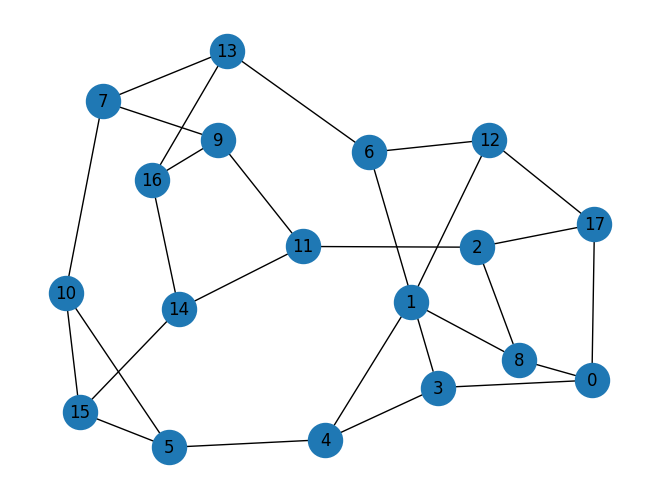

In [38]:
n = 18
G = generate_k_regular_graph(num_vertices=n, k=3, weighted=True)
draw_graph(G, node_size=600, with_labels=True)

In [ ]:
def build_max_cut_paulis(graph: rx.PyGraph) -> list[tuple[str, float]]:
    """Convert the graph to Pauli list.

    This function does the inverse of `build_max_cut_graph`
    """
    pauli_list = []
    for edge in list(graph.edge_list()):
        paulis = ["I"] * len(graph)
        paulis[edge[0]], paulis[edge[1]] = "Z", "Z"

        weight = graph.get_edge_data(edge[0], edge[1])

        pauli_list.append(("".join(paulis)[::-1], weight))

    return pauli_list

max_cut_paulis = build_max_cut_paulis(G)

cost_hamiltonian = SparsePauliOp.from_list(max_cut_paulis)
print("Cost Function Hamiltonian:", cost_hamiltonian)
paulis,coeffs = cost_hamiltonian.paulis.to_labels(),cost_hamiltonian.coeffs.real

Cost Function Hamiltonian: SparsePauliOp(['IIIIIZIIIIIZIIIIII', 'IIIIIIIIIZIIIIIZII', 'IZIZIIIIIIIIIIIIII', 'IIIIZIIIIIZIIIIIII', 'IIIIIZIIIIIIIIIIZI', 'IIIIIIIIIIIIIZIIZI', 'IZIIZIIIIIIIIIIIII', 'IIIIIIIIIZIIIIIIIZ', 'IIIIIIIIIIIZIIZIII', 'IIIIZIIIIIIZIIIIII', 'IIZIIIIZIIIIIIIIII', 'IIIIIIIIIIIIIIZIIZ', 'ZIIIIIIIIIIIIIIIIZ', 'IIIIIIZIZIIIIIIIII', 'IIIIIIIIZIZIIIIIII', 'IIIIIIIIIIIIIZZIII', 'IIZIIIIIIIIIZIIIII', 'IIIZIIZIIIIIIIIIII', 'ZIIIIZIIIIIIIIIIII', 'IIIIIIIZIIIIZIIIII', 'IIZZIIIIIIIIIIIIII', 'IIIIIIIIIZIIIIIIZI', 'IIIIIIZIIIIIIIIZII', 'IIIIIIIIIIIIZZIIII', 'IIIIIIIZIIZIIIIIII', 'ZIIIIIIIIIIIIIIZII', 'IZIIIIIIZIIIIIIIII'],
              coeffs=[ 6.+0.j,  2.+0.j,  4.+0.j, 10.+0.j,  4.+0.j,  4.+0.j,  3.+0.j,  9.+0.j,
  8.+0.j,  5.+0.j,  2.+0.j,  4.+0.j,  2.+0.j,  8.+0.j,  4.+0.j,  1.+0.j,
  1.+0.j,  9.+0.j,  7.+0.j, 10.+0.j,  2.+0.j,  5.+0.j,  2.+0.j,  4.+0.j,
  2.+0.j,  5.+0.j,  6.+0.j])


In [4]:

reps = 1
gamma_params = [Parameter(f'gamma_{i}_{j}_{r}') for r in range(reps) for i, j in G.edge_list()]
beta_params = [Parameter(f'beta_{i}_{r}') for r in range(reps) for i in G.node_indexes()]

circuit = multi_angle_qaoa_circuit(gamma_params,beta_params,n,G ,reps)

In [5]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime.fake_provider import FakeManilaV2,FakeNairobiV2,FakeMelbourneV2,FakeGuadalupeV2

In [6]:
# Transform qiskit circ. to stim.
modified_circ = modify_circuit(circuit)
pcirc = transform_to_allowed_gates(modified_circ)

pcirc.draw('mpl')

stim_circ = qiskit_to_stim(pcirc)
stim_circ.stim_circuit().diagram()

q0: -H-@---@-@---@-------@---@-------------@---@-S-SQRT_X-I-SQRT_X-S-------------------------------------------------------------------------------------------
       |   | |   |       |   |             |   |
q1: -H-X-I-X-|---|-@---@-|---|-@---@-------|---|-------------------@---@-S-SQRT_X-I-SQRT_X-S-------------------------------------------------------------------
             |   | |   | |   | |   |       |   |                   |   |
q2: -------H-X-I-X-X-I-X-|---|-|---|-@---@-|---|-------------------|---|-------------------@---@-S-SQRT_X-I-SQRT_X-S-------------------------------------------
                         |   | |   | |   | |   |                   |   |                   |   |
q3: -------------------H-X-I-X-X-I-X-X-I-X-|---|-------------------|---|-------------------|---|-------------------@---@-S-SQRT_X-I-SQRT_X-S-------------------
                                           |   |                   |   |                   |   |                   |   |
q4: -------------------------------------H-X-I-X-------------------X-I-X-------------------X-I-X-------------------X-I-X-------------------S-SQRT_X-I-SQRT_X-S-

In [7]:
def qiskit_params_map(circ):
    dag = circuit_to_dag(circ)
    param_list = [list(node.op.params[0].parameters)[0].name for node in dag.op_nodes() if node.op.params and isinstance(node.op.params[0], ParameterExpression)]
    return {k: v for v, k in enumerate(param_list)}

qiskit_param_map = qiskit_params_map(pcirc)

# Ensure the sorted names are correct
ordered_params = [param.name for param in pcirc.parameters]
assert sorted(qiskit_param_map.keys()) == ordered_params

param_map = {qiskit_param_map[param]: i for i, param in enumerate(ordered_params)}
param_map

{7: 0,
 9: 1,
 11: 2,
 13: 3,
 14: 4,
 0: 5,
 1: 6,
 3: 7,
 6: 8,
 2: 9,
 4: 10,
 8: 11,
 5: 12,
 10: 13,
 12: 14}

In [9]:
stim_circ.define_parameter_map(param_map)

## CAFQA to find best initial params

In [ ]:
# we can perform CAFQA by using the main optimization function "claptonize"

ks_best, _, energy_best = claptonize(
    paulis,
    coeffs,
    stim_circ,
    n_proc=4,           # total number of processes in parallel
    n_starts=4,         # number of random genetic algorithm starts in parallel
    n_rounds=1,         # number of budget rounds, if None it will terminate itself
    callback=print,     # callback for internal parameter (#iteration, energies, ks) processing
    budget=20           # budget per genetic algorithm instance
)

STARTING ROUND 0


started GA at id 1 with 1 procs

started GA at id 2 with 1 procs

started GA at id 3 with 1 procs



/global/homes/d/dhanvib/.conda/envs/qaoa/lib/python3.10/site-packages/pygad/pygad.py:1139: UserWarning: The 'delay_after_gen' parameter is deprecated starting from PyGAD 3.3.0. To delay or pause the evolution after each generation, assign a callback function/method to the 'on_generation' parameter to adds some time delay.
  warnings.warn("The 'delay_after_gen' parameter is deprecated starting from PyGAD 3.3.0. To delay or pause the evolution after each generation, assign a callback function/method to the 'on_generation' parameter to adds some time delay.")


GA parameters used for this experiment:
  num_generations=20
  num_parents_mating=20
  population_size=100
  num_genes=15
  parent_selection_type=tournament
  keep_parents=-1
  crossover_type=single_point
  mutation_type=adaptive
  crossover_probability=0.9
  mutation_probability=(0.25, 0.01)
  keep_elitism=10

/global/homes/d/dhanvib/.conda/envs/qaoa/lib/python3.10/site-packages/pygad/pygad.py:1139: UserWarning: The 'delay_after_gen' parameter is deprecated starting from PyGAD 3.3.0. To delay or pause the evolution after each generation, assign a callback function/method to the 'on_generation' parameter to adds some time delay.
  warnings.warn("The 'delay_after_gen' parameter is deprecated starting from PyGAD 3.3.0. To delay or pause the evolution after each generation, assign a callback function/method to the 'on_generation' parameter to adds some time delay.")


started GA at id None with 1 procs

GA parameters used for this experiment:
  num_generations=20
  num_parents_mating=20
  population_size=100
  num_genes=15
  parent_selection_type=tournament
  keep_parents=-1
  crossover_type=single_point
  mutation_type=adaptive
  crossover_probability=0.9
  mutation_probability=(0.25, 0.01)
  keep_elitism=10
GA parameters used for this experiment:
  num_generations=20
  num_parents_mating=20
  population_size=100
  num_genes=15
  parent_selection_type=tournament
  keep_parents=-1
  crossover_type=single_point
  mutation_type=adaptive
  crossover_probability=0.9
  mutation_probability=(0.25, 0.01)
  keep_elitism=10

...

/global/homes/d/dhanvib/.conda/envs/qaoa/lib/python3.10/site-packages/pygad/pygad.py:1139: UserWarning: The 'delay_after_gen' parameter is deprecated starting from PyGAD 3.3.0. To delay or pause the evolution after each generation, assign a callback function/method to the 'on_generation' parameter to adds some time delay.
  warnings.warn("The 'delay_after_gen' parameter is deprecated starting from PyGAD 3.3.0. To delay or pause the evolution after each generation, assign a callback function/method to the 'on_generation' parameter to adds some time delay.")


started GA at id None with 1 procs

GA parameters used for this experiment:
  num_generations=20
  num_parents_mating=20
  population_size=100
  num_genes=15
  parent_selection_type=tournament
  keep_parents=-1
  crossover_type=single_point
  mutation_type=adaptive
  crossover_probability=0.9
  mutation_probability=(0.25, 0.01)
  keep_elitism=10
GA parameters used for this experiment:
  num_generations=20
  num_parents_mating=20
  population_size=100
  num_genes=15
  parent_selection_type=tournament
  keep_parents=-1
  crossover_type=single_point
  mutation_type=adaptive
  crossover_probability=0.9
  mutation_probability=(0.25, 0.01)
  keep_elitism=10

/global/homes/d/dhanvib/.conda/envs/qaoa/lib/python3.10/site-packages/pygad/pygad.py:1139: UserWarning: The 'delay_after_gen' parameter is deprecated starting from PyGAD 3.3.0. To delay or pause the evolution after each generation, assign a callback function/method to the 'on_generation' parameter to adds some time delay.
  warnings.warn("The 'delay_after_gen' parameter is deprecated starting from PyGAD 3.3.0. To delay or pause the evolution after each generation, assign a callback function/method to the 'on_generation' parameter to adds some time delay.")


/global/homes/d/dhanvib/.conda/envs/qaoa/lib/python3.10/site-packages/pygad/pygad.py:1139: UserWarning: The 'delay_after_gen' parameter is deprecated starting from PyGAD 3.3.0. To delay or pause the evolution after each generation, assign a callback function/method to the 'on_generation' parameter to adds some time delay.
  warnings.warn("The 'delay_after_gen' parameter is deprecated starting from PyGAD 3.3.0. To delay or pause the evolution after each generation, assign a callback function/method to the 'on_generation' parameter to adds some time delay.")


GA parameters used for this experiment:
  num_generations=20
  num_parents_mating=20
  population_size=100
  num_genes=15
  parent_selection_type=tournament
  keep_parents=-1
  crossover_type=single_point
  mutation_type=adaptive
  crossover_probability=0.9
  mutation_probability=(0.25, 0.01)
  keep_elitism=10
This is the energy of current sol. : 0.0
This is the energy of current sol. : 0.0
This is the energy of current sol. : 0.0
This is the energy of current sol. : 0.0
This is the energy of current sol. : 14.0
This is the energy of current sol. : 14.0
This is the energy of current sol. : 0.0
This is the energy of current sol. : 0.0
This is the energy of current sol. : 7.0
This is the energy of current sol. : 7.0
This is the energy of current sol. : 0.0
This is the energy of current sol. : 0.0
This is the energy of current sol. : -7.0
This is the energy of current sol. : -7.0
This is the energy of current sol. : 0.0
This is the energy of current sol. : 0.0
This is the energy of curren

In [ ]:
energy_best

In [ ]:
stim_circ.assign(ks_best)
stim_circ.stim_circuit().diagram()

In [ ]:
ks_best

In [ ]:
# initial_gamma = np.pi
# initial_beta = np.pi/2
# init_params = [initial_gamma,initial_beta] * reps

init_params = [param * (np.pi / 4) for param in stim_circ.internal_read()] #This has to be in the order we come across the gates.

In [ ]:
def cafqa_params_energy(circuit, hamiltonian, parameters):
    estimator = Estimator(mode=AerSimulator(method='statevector'))
    isa_hamiltonian = hamiltonian.apply_layout(circuit.layout)

    pub = (circuit, isa_hamiltonian, parameters)
    job = estimator.run([pub])

    results = job.result()[0]
    return results.data.evs

energy = cafqa_params_energy(pcirc, cost_hamiltonian, np.random.random(len(init_params)))
print(energy)

In [ ]:
objective_func_vals = []

def cost_func_estimator(params, ansatz, hamiltonian, estimator):
    global objective_func_vals

    # transform the observable defined on virtual qubits to
    # an observable defined on all physical qubits
    isa_hamiltonian = hamiltonian.apply_layout(ansatz.layout)

    pub = (ansatz, isa_hamiltonian, params)
    job = estimator.run([pub])

    results = job.result()[0]
    cost = results.data.evs

    objective_func_vals.append(cost)

    return cost

In [ ]:
from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator
from scipy.optimize import minimize

# estimator = Estimator(mode=backend)
estimator = Estimator(mode=AerSimulator(method='statevector'))

result = minimize(
    cost_func_estimator,
    init_params,
    args=(circuit, cost_hamiltonian, estimator),
    method="COBYLA",
    tol=1e-3,
)
print(result)

In [ ]:
# Solve with classical Eigensolver for comparison
eigensolver = NumPyMinimumEigensolver()
exact_solution = eigensolver.compute_minimum_eigenvalue(cost_hamiltonian).eigenvalue.real
print("Exact Energy from Eigensolver:", exact_solution)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(objective_func_vals)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()

In [ ]:
optimized_circuit = candidate_circuit.assign_parameters(result.x)
optimized_circuit.measure_all()
optimized_circuit.draw('mpl', fold=False, idle_wires=False)

In [ ]:
from qiskit_ibm_runtime import SamplerV2 as Sampler

# If using qiskit-ibm-runtime<0.24.0, change `mode=` to `backend=`
sampler = Sampler(mode=backend)
sampler.options.default_shots = 10000

pub= (optimized_circuit, )
job = sampler.run([pub], shots=int(1e4))
counts_int = job.result()[0].data.meas.get_int_counts()
counts_bin = job.result()[0].data.meas.get_counts()
shots = sum(counts_int.values())
final_distribution_int = {key: val/shots for key, val in counts_int.items()}
final_distribution_bin = {key: val/shots for key, val in counts_bin.items()}
print(final_distribution_int)

In [ ]:
# auxiliary functions to sample most likely bitstring
def to_bitstring(integer, num_bits):
    result = np.binary_repr(integer, width=num_bits)
    return [int(digit) for digit in result]

keys = list(final_distribution_int.keys())
values = list(final_distribution_int.values())
most_likely = keys[np.argmax(np.abs(values))]
most_likely_bitstring = to_bitstring(most_likely, len(G))
most_likely_bitstring.reverse()

print("Result bitstring:", most_likely_bitstring)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams.update({"font.size": 10})
final_bits = final_distribution_bin
values = np.abs(list(final_bits.values()))
top_4_values = sorted(values, reverse=True)[:4]
positions = []
for value in top_4_values:
    positions.append(np.where(values == value)[0][0])
fig = plt.figure(figsize=(11, 6))
ax = fig.add_subplot(1, 1, 1)
plt.xticks(rotation=45)
plt.title("Result Distribution")
plt.xlabel("Bitstrings (reversed)")
plt.ylabel("Probability")
ax.bar(list(final_bits.keys()), list(final_bits.values()), color="tab:grey")
for p in positions:
    ax.get_children()[int(p)].set_color("tab:purple")
plt.show()

In [ ]:
# auxiliary function to plot graphs
def plot_result(G, x):
    colors = ["tab:grey" if i == 0 else "tab:purple" for i in x]
    pos, default_axes = rx.spring_layout(G), plt.axes(frameon=True)
    rx.visualization.mpl_draw(G, node_color=colors, node_size=100, alpha=0.8, pos=pos)

plot_result(G, most_likely_bitstring)

In [ ]:
from typing import Sequence
def evaluate_sample(x: Sequence[int], graph: rx.PyGraph) -> float:
    assert len(x) == len(list(graph.nodes())), "The length of x must coincide with the number of nodes in the graph."
    return sum(x[u] * (1 - x[v]) + x[v] * (1 - x[u]) for u, v in list(graph.edge_list()))


cut_value= evaluate_sample(most_likely_bitstring, G)
print('The value of the cut is:', cut_value)